# Melhorando EEGNet para Motor Imagery BCI

**Baseline**: EEGNet 4-class, Subject 1, acc=66.7%, kappa=0.556

**Objetivo**: Maximizar acurácia no test set para integração com jogo online (left/right)

**Roteiro de melhorias**:
1. Redução para 2 classes (left hand vs right hand)
2. Ajuste de banda (8-30 Hz, foco em mu/beta)
3. Data augmentation: Gaussian noise
4. Data augmentation: sliding window temporal
5. Pipeline completo + comparação
6. Salvar melhor modelo para uso online

## 0. Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import mne
from mne.io import read_raw_gdf
from scipy.io import loadmat

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, Flatten, Dense
)
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

mne.set_log_level('WARNING')
print(f'MNE {mne.__version__} | TF {tf.__version__}')

MNE 1.12.1 | TF 2.21.0


In [4]:
# --- Paths & Constants ---
NOTEBOOK_DIR = Path(r'C:\Users\pedro\Workspaces\EEG_learning')
DATA_DIR     = NOTEBOOK_DIR / 'data' / 'bcic_iv_2a'
LABELS_DIR   = NOTEBOOK_DIR / 'data' / 'true_labels'
MODELS_DIR   = NOTEBOOK_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

SFREQ      = 250
N_CHANNELS = 22
SUBJECT_ID = 1

# Tracker de resultados: {nome_experimento: {acc, kappa, n_train}}
results = {}

In [7]:
# --- Infraestrutura (fornecida) ---

def build_eegnet(
    n_channels: int  = 22,
    n_times: int     = 1001,
    n_classes: int   = 2,
    sfreq: int       = 250,
    F1: int          = 8,
    D: int           = 2,
    F2: int          = 16,
    dropout_rate: float = 0.5,
) -> Model:
    kern_len = sfreq // 2
    inputs = Input(shape=(1, n_channels, n_times), name='eeg_input')

    x = Conv2D(F1, (1, kern_len), padding='same', use_bias=False,
               data_format='channels_first', name='temporal_conv')(inputs)
    x = BatchNormalization(axis=1)(x)

    x = DepthwiseConv2D((n_channels, 1), depth_multiplier=D,
                        depthwise_constraint=max_norm(1.0), use_bias=False,
                        data_format='channels_first', name='spatial_conv')(x)
    x = BatchNormalization(axis=1)(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4), data_format='channels_first')(x)
    x = Dropout(dropout_rate)(x)

    x = SeparableConv2D(F2, (1, 16), padding='same', use_bias=False,
                        data_format='channels_first', name='separable_conv')(x)
    x = BatchNormalization(axis=1)(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 8), data_format='channels_first')(x)
    x = Dropout(dropout_rate)(x)

    x = Flatten()(x)
    outputs = Dense(n_classes, activation='softmax',
                    kernel_constraint=max_norm(0.25), name='classifier')(x)

    return Model(inputs, outputs, name='EEGNet')


def normalize_per_epoch(X: np.ndarray) -> np.ndarray:
    mu  = X.mean(axis=(1, 2), keepdims=True)
    std = X.std(axis=(1, 2), keepdims=True) + 1e-8
    return (X - mu) / std


def reshape_for_eegnet(X: np.ndarray) -> np.ndarray:
    return X[:, np.newaxis, :, :]  # (n, 1, C, T)


def prepare(X: np.ndarray) -> np.ndarray:
    """Normalize + reshape em um passo."""
    return reshape_for_eegnet(normalize_per_epoch(X))


def train_and_evaluate(X_train, y_train, X_test, y_test,
                       n_classes=2, experiment_name='exp',
                       epochs=300, batch_size=32, patience=20):
    """Treina EEGNet e retorna métricas. Salva no dict results."""
    n_times = X_train.shape[-1]
    model = build_eegnet(N_CHANNELS, n_times, n_classes, SFREQ)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    history = model.fit(
        X_train, y_train,
        epochs=epochs, batch_size=batch_size,
        validation_split=0.2,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=patience,
                          restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=10, min_lr=1e-5),
        ],
        verbose=1,
    )

    y_pred = np.argmax(model.predict(X_test), axis=1)
    acc   = (y_pred == y_test).mean()
    kappa = cohen_kappa_score(y_test, y_pred)

    results[experiment_name] = {
        'accuracy': acc, 'kappa': kappa,
        'n_train': len(X_train), 'n_test': len(X_test),
    }
    print(f'\n=== {experiment_name} ===')
    print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
    print(f'Accuracy: {acc:.4f} | Kappa: {kappa:.4f}')
    print(classification_report(y_test, y_pred,
          target_names=['Left Hand', 'Right Hand'][:n_classes]))

    return model, history

print('Infraestrutura carregada.')

Infraestrutura carregada.


---
## Exercício 1 — Baseline 2 Classes (Left Hand vs Right Hand)

### Pense Primeiro

No notebook anterior, tínhamos 4 classes com acurácia de 66.7%. Se reduzirmos para 2 classes:
- O que acontece com o *chance level*?
- Olhando a matriz de confusão anterior, Left Hand tinha 67% recall e Right Hand 94%. De onde vinham os erros dessas classes? Eram confusões *entre si* ou com Feet/Tongue?
- Eliminar Feet e Tongue remove confusão ou remove informação útil?

### Contexto

A imaginação motora de mão esquerda vs mão direita produz padrões de **ERD/ERS contralateral** — quando você imagina mover a mão direita, o ritmo mu (8-13 Hz) *dessincroniza* sobre o córtex motor esquerdo (eletrodo C3) e pode *sincronizar* no lado ipsilateral (C4). O padrão é espelhado para mão esquerda.

Isso significa que left vs right é o par de classes com a **separabilidade neurofisiológica mais clara** — os padrões são literalmente em hemisférios opostos do cérebro. Feet e tongue usam representações corticais na linha mediana (Cz), que são mais difíceis de separar e podem causar confusão.

### Exercício

Implemente `load_subject_2class` — uma versão modificada de `load_subject` que retorna apenas trials de left hand (label 0) e right hand (label 1).

In [8]:
def load_subject_2class(subject_id: int, split: str = 'T',
                        l_freq: float = 4.0, h_freq: float = 40.0):
    """
    Load one subject, keeping only left hand (0) and right hand (1).

    Returns:
        X: (n_epochs, 22, n_times) float32
        y: (n_epochs,) int32, values in {0, 1}
    """
    fname = DATA_DIR / f'A0{subject_id}{split}.gdf'
    raw = read_raw_gdf(str(fname), preload=True, verbose=False)

    raw.pick_types(eeg=True)
    raw.pick(raw.ch_names[:N_CHANNELS])
    raw.filter(l_freq=l_freq, h_freq=h_freq, method='iir', verbose=False)

    if split == 'T':
        # Training: só left hand (769) e right hand (770)
        event_id = {'left_hand': 769, 'right_hand': 770}
        ann_to_code = {str(v): v for v in event_id.values()}
        events, _ = mne.events_from_annotations(raw, event_id=ann_to_code, verbose=False)
        events = events[np.isin(events[:, 2], list(event_id.values()))]

        epochs = mne.Epochs(raw, events, event_id=event_id,
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        X = epochs.get_data().astype(np.float32)
        # 769 -> 0 (left), 770 -> 1 (right)
        y = np.array([0 if c == 769 else 1 for c in epochs.events[:, 2]], dtype=np.int32)

    else:
        # Evaluation: todos os onsets são code 783, labels vêm do .mat
        events, _ = mne.events_from_annotations(raw, event_id={'783': 783}, verbose=False)
        epochs = mne.Epochs(raw, events, event_id={'cue': 783},
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        X = epochs.get_data().astype(np.float32)

        mat = loadmat(str(LABELS_DIR / f'A0{subject_id}E.mat'))
        labels = mat['classlabel'].flatten() - 1  # 0=left, 1=right, 2=feet, 3=tongue
        labels = labels[:len(X)]

        # Filtrar só left (0) e right (1)
        mask = np.isin(labels, [0, 1])
        X = X[mask]
        y = labels[mask].astype(np.int32)

    return X, y


# --- Teste ---
X_train, y_train = load_subject_2class(SUBJECT_ID, 'T')
X_test,  y_test  = load_subject_2class(SUBJECT_ID, 'E')
print(f'Train: {X_train.shape}, y: {np.unique(y_train, return_counts=True)}')
print(f'Test:  {X_test.shape},  y: {np.unique(y_test,  return_counts=True)}')

C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Train: (144, 22, 1001), y: (array([0, 1], dtype=int32), array([72, 72]))
Test:  (144, 22, 1001),  y: (array([0, 1], dtype=int32), array([72, 72]))


In [9]:
# --- Treinar baseline 2-class ---

X_train_prep = prepare(X_train)
X_test_prep  = prepare(X_test)

model_baseline, hist_baseline = train_and_evaluate(
    X_train_prep, y_train, X_test_prep, y_test,
    n_classes=2, experiment_name='baseline_2class'
)

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step - accuracy: 0.5478 - loss: 0.6968 - val_accuracy: 0.4828 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.6348 - loss: 0.6790 - val_accuracy: 0.5172 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.5130 - loss: 0.6871 - val_accuracy: 0.4138 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.5739 - loss: 0.6859 - val_accuracy: 0.4828 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.5913 - loss: 0.6837 - val_accuracy: 0.4828 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.5826 - loss: 0.6806 - val_accuracy: 0.5862 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.5826 - loss: 0.6672 - val_acc

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


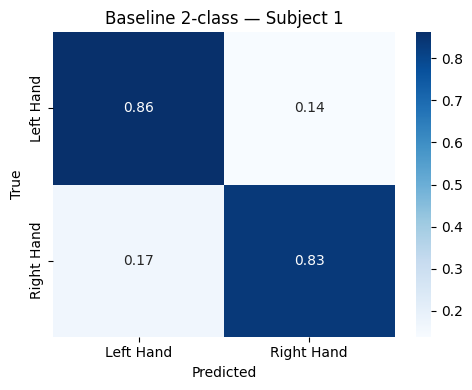

Counts:
  Left  predicted as Left:  62  | as Right: 10
  Right predicted as Left:  12  | as Right: 60


In [10]:
# --- Confusion Matrix: Baseline 2-class ---
y_pred_baseline = np.argmax(model_baseline.predict(X_test_prep), axis=1)

cm = confusion_matrix(y_test, y_pred_baseline, normalize='true')
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Left Hand', 'Right Hand'],
            yticklabels=['Left Hand', 'Right Hand'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title(f'Baseline 2-class — Subject {SUBJECT_ID}')
plt.tight_layout()
plt.show()

# Counts version
cm_counts = confusion_matrix(y_test, y_pred_baseline)
print('Counts:')
print(f'  Left  predicted as Left:  {cm_counts[0,0]}  | as Right: {cm_counts[0,1]}')
print(f'  Right predicted as Left:  {cm_counts[1,0]}  | as Right: {cm_counts[1,1]}')

### Reflexão

- Quanto a acurácia subiu em relação ao baseline de 4 classes (66.7%)?
- O recall ficou equilibrado entre as duas classes ou uma domina?
- Com 144 trials de treino (vs 288 no 4-class), o overfitting ficou melhor ou pior?

---
## Exercício 2 — Ajuste de Banda: Foco em Mu/Beta (8-30 Hz)

### Pense Primeiro

O filtro atual é 4-40 Hz. Pense no que cada faixa de frequência contém:
- **4-8 Hz (theta)**: atividade atencional, memória de trabalho — relevante para MI?
- **8-13 Hz (mu/alpha)**: ritmo sensorimotor — onde mora o ERD/ERS de motor imagery
- **13-30 Hz (beta)**: rebound motor, sincronização pós-movimento
- **30-40 Hz (gamma baixo)**: processamento cognitivo de alto nível, mas também muito artefato muscular (EMG)

Se incluímos theta e gamma, estamos adicionando **sinal relevante** ou **ruído** para o problema de MI?

### Contexto

A literatura de motor imagery BCI converge em 8-30 Hz como a banda ótima. O ritmo **mu** (8-13 Hz, centrado em ~10 Hz) é o principal marcador — ele dessincroniza (ERD) durante imaginação motora sobre o córtex motor contralateral. O ritmo **beta** (13-30 Hz) complementa com o *beta rebound* — uma sincronização que ocorre após o período de imaginação.

Incluir 4-8 Hz adiciona atividade theta que é mais relacionada a atenção/memória e varia muito entre trials. Incluir 30-40 Hz traz artefatos de EMG (contração muscular) que podem confundir o classificador.

### Exercício

Recarregue os dados com banda 8-30 Hz e retreine o modelo.

C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 0.5391 - loss: 0.6947 - val_accuracy: 0.4828 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.5304 - loss: 0.6890 - val_accuracy: 0.4828 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.5217 - loss: 0.6927 - val_accuracy: 0.5172 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.6261 - loss: 0.6798 - val_accuracy: 0.5172 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.6174 - loss: 0.6726 - val_accuracy: 0.4483 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.6000 - loss: 0.6830 - val_accuracy: 0.5172 - val_loss: 0.6926 - learning_rate: 0.0010
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.6261 - loss: 0.6732 - val_acc

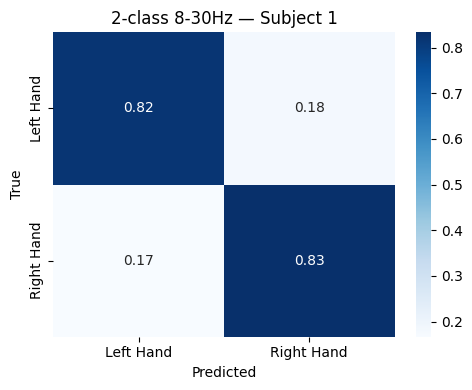

In [12]:
# --- Exercício 2: Recarregar com banda 8-30 Hz ---

X_train_band, y_train_band = load_subject_2class(SUBJECT_ID, 'T', l_freq=8.0, h_freq=30.0)
X_test_band,  y_test_band  = load_subject_2class(SUBJECT_ID, 'E', l_freq=8.0, h_freq=30.0)

X_train_band_prep = prepare(X_train_band)
X_test_band_prep  = prepare(X_test_band)

model_band, hist_band = train_and_evaluate(
    X_train_band_prep, y_train_band, X_test_band_prep, y_test_band,
    n_classes=2, experiment_name='2class_8-30Hz'
)

# --- Confusion Matrix ---
y_pred_band = np.argmax(model_band.predict(X_test_band_prep), axis=1)

cm = confusion_matrix(y_test_band, y_pred_band, normalize='true')
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Left Hand', 'Right Hand'],
            yticklabels=['Left Hand', 'Right Hand'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title(f'2-class 8-30Hz — Subject {SUBJECT_ID}')
plt.tight_layout()
plt.show()

### Reflexão

- A acurácia melhorou, piorou, ou ficou estável em relação ao baseline 2-class?
- Se melhorou: o ganho veio de qual classe? Olhe recall por classe.
- Se não melhorou: pode ser que o EEGNet já esteja aprendendo a ignorar as bandas irrelevantes internamente (a primeira camada convolucional é um filtro temporal aprendido). O que isso diz sobre a capacidade da rede?

---
## Exercício 3 — Data Augmentation: Gaussian Noise Injection

### Pense Primeiro

Temos ~144 trials de treino para 2 classes. Um modelo com ~4000 parâmetros pode facilmente decorar 144 exemplos.

- Se você adicionar ruído gaussiano a uma época de EEG, o conteúdo neural (ERD/ERS) é destruído?
- Qual seria um nível razoável de ruído? Se o sinal tem std=1 (após z-score), quanto de noise você adicionaria?
- Se gerar 5 cópias ruidosas de cada trial, o dataset vai de 144 para quantos trials?

### Contexto

EEG é inerentemente ruidoso — cada trial tem ruído de fundo diferente (atividade neural espontânea, artefatos sutis, variação de impedância). O sinal de motor imagery (ERD/ERS) é uma modulação **relativamente lenta** na potência de mu/beta, então é robusto a ruído aditivo de alta frequência.

Gaussian noise injection simula essa variabilidade natural: cada cópia augmentada é como um "trial alternativo" onde o sujeito fez a mesma imaginação mas com ruído de fundo diferente. A chave é calibrar a amplitude do ruído — alto demais destrói o sinal, baixo demais não ajuda.

Uma regra de partida: `noise_std` entre 0.05 e 0.2 relativo ao std da época.

### Exercício

Implemente a função de augmentation e treine com dados aumentados.

In [13]:
def augment_gaussian_noise(X, y, n_copies=5, noise_std=0.1):
    """
    Gera n_copies versões ruidosas de cada época.
    noise_std é relativo ao std de cada época individual.
    """
    augmented = [X]          # começa com os originais
    labels    = [y]

    for _ in range(n_copies):
        # std por época: shape (n, 1, 1) para broadcast sobre (n, C, T)
        epoch_std = X.std(axis=(1, 2), keepdims=True)

        # ruído com mesma shape de X, escalado pelo std de cada época
        noise = np.random.randn(*X.shape).astype(np.float32) * (noise_std * epoch_std)

        augmented.append(X + noise)
        labels.append(y)

    return np.concatenate(augmented), np.concatenate(labels)


# --- Teste rápido ---
X_demo = np.random.randn(10, 22, 100).astype(np.float32)
y_demo = np.array([0,1,0,1,0,1,0,1,0,1])
X_a, y_a = augment_gaussian_noise(X_demo, y_demo, n_copies=3, noise_std=0.1)
print(f'Original: {X_demo.shape} -> Augmented: {X_a.shape}')
assert X_a.shape[0] == 10 + 10*3 == 40
print('OK!')

Original: (10, 22, 100) -> Augmented: (40, 22, 100)
OK!


Treino original: 144 -> Augmented: 864 trials
Epoch 1/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.5470 - loss: 0.6900 - val_accuracy: 0.6821 - val_loss: 0.6909 - learning_rate: 0.0010
Epoch 2/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.6368 - loss: 0.6640 - val_accuracy: 0.7225 - val_loss: 0.6872 - learning_rate: 0.0010
Epoch 3/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.7221 - loss: 0.6343 - val_accuracy: 0.7572 - val_loss: 0.6807 - learning_rate: 0.0010
Epoch 4/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.7381 - loss: 0.6088 - val_accuracy: 0.7803 - val_loss: 0.6719 - learning_rate: 0.0010
Epoch 5/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.7685 - loss: 0.5809 - val_accuracy: 0.7919 - val_loss: 0.6608 - learning_rate: 0.0010
Epoch 6/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.7916 - loss: 0.5589 - val_accuracy: 0.8035 - val_loss: 0.6468 - learning_rate: 0.0010
Epoch 7/300
22/22 ━━━━━━━━━━━━━━━━━━

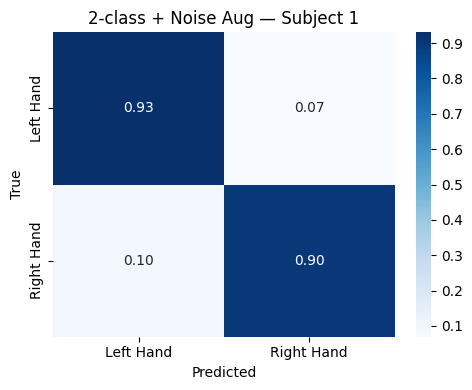

In [14]:
# --- Exercício 3: Treinar com noise augmentation ---
# Usando banda 4-40 Hz (melhor que 8-30 Hz no Ex.2)

# Augmentar dados BRUTOS de treino (antes de normalizar!)
X_train_aug, y_train_aug = augment_gaussian_noise(X_train, y_train, n_copies=5, noise_std=0.1)
print(f'Treino original: {X_train.shape[0]} -> Augmented: {X_train_aug.shape[0]} trials')

# Normalizar e reshape DEPOIS de augmentar
X_train_aug_prep = prepare(X_train_aug)
X_test_prep      = prepare(X_test)       # teste nunca recebe augmentation

model_noise, hist_noise = train_and_evaluate(
    X_train_aug_prep, y_train_aug, X_test_prep, y_test,
    n_classes=2, experiment_name='2class_noise_aug'
)

# --- Confusion Matrix ---
y_pred_noise = np.argmax(model_noise.predict(X_test_prep), axis=1)

cm = confusion_matrix(y_test, y_pred_noise, normalize='true')
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Left Hand', 'Right Hand'],
            yticklabels=['Left Hand', 'Right Hand'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title(f'2-class + Noise Aug — Subject {SUBJECT_ID}')
plt.tight_layout()
plt.show()

### Reflexão

- O gap entre train accuracy e val accuracy diminuiu? (Isso indica menos overfitting)
- Experimente variar `noise_std` (0.05, 0.1, 0.2) e `n_copies` (3, 5, 10). Qual combinação dá o melhor test accuracy?
- Se aumentar demais o ruído, o que acontece? Por quê?

---
## Report Pós-Augmentation: 4 Classes vs 2 Classes

Comparação de métricas (Accuracy, R², Cohen's Kappa, F1) após Gaussian Noise Augmentation para os cenários de **4 classes** (left hand, right hand, feet, tongue) e **2 classes** (left hand, right hand).

In [ ]:
from sklearn.metrics import r2_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize

# --- Loader 4-class ---
def load_subject_4class(subject_id: int, split: str = 'T',
                        l_freq: float = 4.0, h_freq: float = 40.0):
    CODE_TO_IDX = {769: 0, 770: 1, 771: 2, 772: 3}
    EVENT_ID = {'left_hand': 769, 'right_hand': 770, 'feet': 771, 'tongue': 772}

    fname = DATA_DIR / f'A0{subject_id}{split}.gdf'
    raw = read_raw_gdf(str(fname), preload=True, verbose=False)
    raw.pick_types(eeg=True)
    raw.pick(raw.ch_names[:N_CHANNELS])
    raw.filter(l_freq=l_freq, h_freq=h_freq, method='iir', verbose=False)

    if split == 'T':
        ann_to_code = {str(k): k for k in CODE_TO_IDX}
        events, _ = mne.events_from_annotations(raw, event_id=ann_to_code, verbose=False)
        events = events[np.isin(events[:, 2], list(CODE_TO_IDX.keys()))]
        epochs = mne.Epochs(raw, events, event_id=EVENT_ID,
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        X = epochs.get_data().astype(np.float32)
        y = np.array([CODE_TO_IDX[c] for c in epochs.events[:, 2]], dtype=np.int32)
    else:
        events, _ = mne.events_from_annotations(raw, event_id={'783': 783}, verbose=False)
        epochs = mne.Epochs(raw, events, event_id={'cue': 783},
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        X = epochs.get_data().astype(np.float32)
        mat = loadmat(str(LABELS_DIR / f'A0{subject_id}E.mat'))
        y = (mat['classlabel'].flatten() - 1).astype(np.int32)
        y = y[:len(X)]

    return X, y

# --- Carregar dados 4-class ---
X_train_4c, y_train_4c = load_subject_4class(SUBJECT_ID, 'T')
X_test_4c,  y_test_4c  = load_subject_4class(SUBJECT_ID, 'E')
print(f'4-class Train: {X_train_4c.shape}, classes: {np.unique(y_train_4c, return_counts=True)}')
print(f'4-class Test:  {X_test_4c.shape},  classes: {np.unique(y_test_4c,  return_counts=True)}')

In [ ]:
# --- Augmentation + Treino 4-class ---
X_train_4c_aug, y_train_4c_aug = augment_gaussian_noise(X_train_4c, y_train_4c, n_copies=5, noise_std=0.1)
print(f'4-class: {X_train_4c.shape[0]} -> {X_train_4c_aug.shape[0]} trials (augmented)')

X_train_4c_aug_prep = prepare(X_train_4c_aug)
X_test_4c_prep      = prepare(X_test_4c)

CLASS_NAMES_4 = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

model_4c_aug, hist_4c_aug = train_and_evaluate(
    X_train_4c_aug_prep, y_train_4c_aug, X_test_4c_prep, y_test_4c,
    n_classes=4, experiment_name='4class_noise_aug'
)

In [ ]:
# ===================================================================
# Report Pós-Augmentation: Métricas Completas — 4 Classes vs 2 Classes
# ===================================================================

def compute_report(model, X_test, y_test, n_classes, class_names):
    """Computa métricas completas: accuracy, R², kappa, F1, precision, recall."""
    y_proba = model.predict(X_test, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)

    acc   = (y_pred == y_test).mean()
    kappa = cohen_kappa_score(y_test, y_pred)

    y_test_oh = label_binarize(y_test, classes=list(range(n_classes)))
    if n_classes == 2:
        y_test_oh = np.hstack([1 - y_test_oh, y_test_oh])
    r2 = r2_score(y_test_oh, y_proba, multioutput='uniform_average')

    f1   = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro')
    rec  = recall_score(y_test, y_pred, average='macro')

    confidence_correct   = y_proba[y_pred == y_test].max(axis=1).mean() if (y_pred == y_test).any() else 0
    confidence_incorrect = y_proba[y_pred != y_test].max(axis=1).mean() if (y_pred != y_test).any() else 0

    return {
        'accuracy': acc, 'r2': r2, 'kappa': kappa,
        'f1_macro': f1, 'precision_macro': prec, 'recall_macro': rec,
        'mean_confidence_correct': confidence_correct,
        'mean_confidence_incorrect': confidence_incorrect,
        'y_pred': y_pred, 'y_proba': y_proba,
    }

# --- 4-class report ---
CLASS_NAMES_2 = ['Left Hand', 'Right Hand']
report_4c = compute_report(model_4c_aug, X_test_4c_prep, y_test_4c, 4, CLASS_NAMES_4)
report_2c = compute_report(model_noise,  X_test_prep,    y_test,    2, CLASS_NAMES_2)

# --- Tabela Comparativa ---
print('=' * 70)
print(f'{"METRIC":<30} {"4 CLASSES":>15} {"2 CLASSES":>15}')
print('=' * 70)
for metric in ['accuracy', 'r2', 'kappa', 'f1_macro', 'precision_macro', 'recall_macro',
               'mean_confidence_correct', 'mean_confidence_incorrect']:
    label = metric.replace('_', ' ').title()
    v4 = report_4c[metric]
    v2 = report_2c[metric]
    print(f'{label:<30} {v4:>15.4f} {v2:>15.4f}')
print('=' * 70)
print(f'{"Train size (augmented)":<30} {len(X_train_4c_aug):>15d} {len(X_train_aug):>15d}')
print(f'{"Test size":<30} {len(X_test_4c):>15d} {len(X_test):>15d}')
print(f'{"Chance level":<30} {"25.0%":>15} {"50.0%":>15}')

In [ ]:
# --- Visualização: Confusion Matrices lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 4-class
cm4 = confusion_matrix(y_test_4c, report_4c['y_pred'], normalize='true')
sns.heatmap(cm4, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES_4, yticklabels=CLASS_NAMES_4)
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')
axes[0].set_title(f'4 Classes + Noise Aug\nAcc={report_4c["accuracy"]:.3f}  R²={report_4c["r2"]:.3f}  κ={report_4c["kappa"]:.3f}')

# 2-class
cm2 = confusion_matrix(y_test, report_2c['y_pred'], normalize='true')
sns.heatmap(cm2, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            xticklabels=CLASS_NAMES_2, yticklabels=CLASS_NAMES_2)
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')
axes[1].set_title(f'2 Classes + Noise Aug\nAcc={report_2c["accuracy"]:.3f}  R²={report_2c["r2"]:.3f}  κ={report_2c["kappa"]:.3f}')

plt.tight_layout()
plt.show()

In [ ]:
# --- Barras comparativas: Accuracy, R², Kappa, F1 ---
metrics_to_plot = ['accuracy', 'r2', 'kappa', 'f1_macro']
labels_plot     = ['Accuracy', 'R²', "Cohen's κ", 'F1 (macro)']

vals_4c = [report_4c[m] for m in metrics_to_plot]
vals_2c = [report_2c[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_4 = ax.bar(x - width/2, vals_4c, width, label='4 Classes', color='steelblue')
bars_2 = ax.bar(x + width/2, vals_2c, width, label='2 Classes', color='darkorange')

ax.set_ylabel('Score')
ax.set_title('Report Pós-Augmentation: 4 Classes vs 2 Classes')
ax.set_xticks(x)
ax.set_xticklabels(labels_plot)
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(y=0.25, color='steelblue', linestyle='--', alpha=0.4, label='Chance 4c (25%)')
ax.axhline(y=0.50, color='darkorange', linestyle='--', alpha=0.4, label='Chance 2c (50%)')

for bar in bars_4:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# --- Distribuição de confiança do softmax ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, report, title, n_cls in [(axes[0], report_4c, '4 Classes', 4),
                                  (axes[1], report_2c, '2 Classes', 2)]:
    y_t = y_test_4c if n_cls == 4 else y_test
    correct = report['y_proba'].max(axis=1)[report['y_pred'] == y_t]
    wrong   = report['y_proba'].max(axis=1)[report['y_pred'] != y_t]

    ax.hist(correct, bins=20, alpha=0.7, label=f'Correct (n={len(correct)})', color='green')
    ax.hist(wrong,   bins=20, alpha=0.7, label=f'Wrong (n={len(wrong)})',   color='red')
    ax.set_xlabel('Max Softmax Confidence')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} — Confidence Distribution')
    ax.legend()
    ax.axvline(x=1/n_cls, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## Exercício 4 — Data Augmentation: Sliding Window Temporal

### Pense Primeiro

Cada trial é uma janela de 4 segundos (0 a 4s pós-cue). Mas pense:
- O padrão de ERD começa exatamente em t=0 ou leva algum tempo para se desenvolver?
- A janela [0.5s, 3.5s] conteria a mesma informação de MI que [0s, 3s]?
- Se extraímos 5 janelas sobrepostas de 3s de cada trial de 4s, quantos exemplos de treino teremos?

Agora pense no contexto do jogo online:
- Se o modelo precisar de 4 segundos de dados para classificar, qual é a latência mínima de resposta?
- Se treinarmos com janelas de 2 segundos, essa latência cai para quanto?

### Contexto

O ERD de motor imagery tipicamente começa ~500ms após o cue e atinge o pico entre 1-2 segundos. Isso significa que uma janela de 2-3 segundos bem posicionada captura a maior parte da informação discriminativa.

Sliding window augmentation explora isso: de cada trial de 4s, extraímos múltiplas sub-janelas sobrepostas. Isso serve dois propósitos:
1. **Multiplica dados** — cada trial gera N sub-janelas
2. **Treina para janelas mais curtas** — essencial para o sistema online (menor latência)

O tradeoff: janelas mais curtas = menos informação temporal = classificação potencialmente pior. Mas com mais exemplos de treino, o modelo generaliza melhor. Na prática, 2-3 segundos é o sweet spot.

**Nota sobre o teste**: no test set, você pode usar uma única janela central, ou classificar múltiplas janelas e fazer **majority voting**.

### Exercício

Implemente sliding window augmentation e treine com janelas mais curtas.

In [ ]:
def augment_sliding_window(X, y, window_sec=2.0, step_sec=0.5, sfreq=250):
    """
    Extrai sub-janelas sobrepostas de cada época.
    
    Args:
        X: (n_epochs, n_channels, n_times)
        y: (n_epochs,)
        window_sec: duração de cada janela em segundos
        step_sec: passo entre janelas em segundos
    
    Returns:
        X_windows: (n_total_windows, n_channels, window_samples)
        y_windows: (n_total_windows,)
    """
    # TODO
    pass


# --- Teste rápido ---
# X_demo = np.random.randn(10, 22, 1001).astype(np.float32)  # 10 trials, 4s
# y_demo = np.zeros(10, dtype=np.int32)
# X_w, y_w = augment_sliding_window(X_demo, y_demo, window_sec=2.0, step_sec=0.5)
# print(f'Original: {X_demo.shape} -> Windows: {X_w.shape}')
# # 4s epoch, 2s window, 0.5s step => 5 windows per trial => 50 total
# # window_samples = 2.0 * 250 = 500

In [ ]:
# TODO: Aplicar sliding window nos dados de treino
# TODO: Para o teste, decidir estratégia:
#   Opção A) janela central única (ex: crop do meio da época)
#   Opção B) múltiplas janelas + majority voting
#
# Dica: Opção B geralmente dá melhor resultado, mas requer um pouco
# mais de lógica. Tente A primeiro, depois B se quiser.

# model_sw, hist_sw = train_and_evaluate(
#     ..., experiment_name='2class_8-30Hz_slidingwindow'
# )

### Reflexão

- Compare o número de trials de treino com vs sem sliding window. Quantas vezes multiplicou?
- A acurácia no test set melhorou em relação ao noise-only?
- Se você usou majority voting no teste: qual foi a acurácia por janela individual vs a acurácia após voting?
- Para o jogo online: qual seria a latência de resposta com janelas de 2s vs 4s?

---
## Exercício 5 — Pipeline Completo: Todas as Melhorias Combinadas

### Pense Primeiro

Agora que você testou cada técnica isoladamente, é hora de combinar:
- Faz sentido aplicar noise augmentation + sliding window ao mesmo tempo?
- Em que ordem você aplicaria? (sliding window primeiro ou noise primeiro?)
- Se combinar tudo, o dataset pode ficar muito grande. Qual é o risco de ter dados demais? (Dica: pense no tempo de treino e no equilíbrio entre dados originais vs augmentados)

### Exercício

Monte o pipeline final combinando: 2 classes + banda 8-30 Hz + sliding window + gaussian noise.

In [ ]:
# TODO: Pipeline completo
# 1. Carregar dados 2-class, banda 8-30 Hz
# 2. Aplicar sliding window no treino
# 3. Aplicar noise augmentation nos windows
# 4. Normalizar e reshape
# 5. Treinar e avaliar
#
# Sugestão de ordem: sliding window ANTES de noise
# (noise em cima de windows curtos é mais realista)
#
# Cuidado com o tamanho: se 144 trials * 5 windows * 5 noise copies = 3600
# Pode ser necessário reduzir n_copies ou aumentar batch_size

# model_full, hist_full = train_and_evaluate(
#     ..., experiment_name='full_pipeline'
# )

---
## Exercício 6 — Comparação Final e Export do Modelo

### Exercício

Plote uma comparação de todos os experimentos e salve o melhor modelo.

In [ ]:
# TODO: Plotar comparação de resultados
# O dict 'results' contém todos os experimentos.
# Crie um gráfico de barras comparando accuracy e kappa.

# print('\n=== Resumo de Resultados ===')
# for name, r in results.items():
#     print(f"{name:30s} | acc={r['accuracy']:.4f} | κ={r['kappa']:.4f} | n_train={r['n_train']}")

In [ ]:
# TODO: Plotar barras de comparação
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# names = list(results.keys())
# accs  = [results[n]['accuracy'] for n in names]
# kappas = [results[n]['kappa'] for n in names]
#
# axes[0].bar(names, accs); axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0.5, 1.0)
# axes[1].bar(names, kappas); axes[1].set_ylabel('Cohen kappa'); axes[1].set_ylim(0.0, 1.0)
# for ax in axes: ax.tick_params(axis='x', rotation=30)
# plt.tight_layout(); plt.show()

In [ ]:
# TODO: Salvar o melhor modelo para uso no jogo online
# best_name = max(results, key=lambda k: results[k]['accuracy'])
# print(f'Melhor experimento: {best_name} (acc={results[best_name]["accuracy"]:.4f})')
#
# Salvar com um nome descritivo:
# model_full.save(MODELS_DIR / 'eegnet_2class_best.keras')
#
# Para uso online, salvar também os metadados de preprocessamento:
# import json
# meta = {
#     'n_channels': N_CHANNELS,
#     'sfreq': SFREQ,
#     'n_classes': 2,
#     'class_names': ['left_hand', 'right_hand'],
#     'l_freq': 8.0,
#     'h_freq': 30.0,
#     'window_sec': 2.0,  # se usou sliding window
#     'window_samples': 500,
#     'normalization': 'zscore_per_epoch',
# }
# with open(MODELS_DIR / 'eegnet_2class_meta.json', 'w') as f:
#     json.dump(meta, f, indent=2)
# print('Modelo e metadados salvos.')

### Reflexão Final

- Qual técnica deu o maior salto de acurácia individual?
- O resultado final é suficiente para controlar o jogo de forma jogável? (Pense: se 1 em cada 5 comandos sai errado, a experiência é frustrante?)
- O que mais poderia ser feito para melhorar? Considere:
  - Treinar subject-specific com fine-tuning de um modelo multi-subject
  - Adicionar um **threshold de confiança** — só enviar comando se softmax > 0.7, caso contrário manter idle
  - Usar **ensemble** de modelos treinados com diferentes augmentations

---

**Próximo passo**: Com o modelo salvo e os metadados de preprocessamento, estamos prontos para montar o módulo de inferência online que conecta no jogo via TCP.